# DIA forced-photometry intranight scatter — a DP2 failure mode

Same field as nb_01/nb_02 (`Rubin_SV_225_-40`).

## 0. Setup

In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.coordinates import SkyCoord
import astropy.units as u

import lsdb
from upath import UPath
from lsst.rsp import RSPDiscovery
from lsst.rsp.utils import get_pyvo_auth
from lsst.images.serialization import read_archive
from pyvo.dal.adhoc import SodaQuery

In [2]:
DATA_DIR = Path("/home/shrra-ung/share/trieste")
hq_cat = lsdb.open_catalog(DATA_DIR / "dia_object_lc_hq")

lsdb_base = UPath("/rubin/lsdb_data/dp2")

discovery = RSPDiscovery("dp2")
sia = discovery.get_sia_client()

field_ra, field_dec = 225.0, -39.5
pool_radius_arcsec = 0.29 * 3600

## 1. Searching for the failure mode

Group `diaObjectForcedSource` points by (night, band); flag any night where the *spread* (p90-p10 among clean points, not max-min -- robust to a single catastrophic point, same convention as nb_01/nb_02's amplitude stat) is both >0.3 mag and >8x the typical reported error for that night. Quality-flag cleaning only (nb_01/nb_02's `science_okflag` recipe) -- no outlier clipping yet, so this measures the raw prevalence.

In [3]:
FLAG_COLS = ['psfFlux_flag', 'pixelFlags_bad', 'pixelFlags_saturatedCenter', 'invalidPsfFlag']

def clean_ok(fs, flag_cols=FLAG_COLS):
    ok = np.ones(len(fs), dtype=bool)
    for c in flag_cols:
        ok &= ~fs[c].to_numpy()
    return ok

def intranight_spreads(fs, ok, mag_col='psfMag', err_col='psfMagErr'):
    """Per clean (night, band) group with >=5 points: (band, night, n, p90-p10 spread, typical_err, median_mag)."""
    t = fs['midpointMjdTai'].to_numpy()
    mag = fs[mag_col].to_numpy()
    err = fs[err_col].to_numpy()
    band = fs['band'].to_numpy()
    valid = ok & np.isfinite(t) & np.isfinite(mag) & np.isfinite(err)
    night = np.floor(t).astype(int)
    out = []
    for b in np.unique(band):
        bm = valid & (band == b)
        if bm.sum() < 5:
            continue
        for n in np.unique(night[bm]):
            sel = bm & (night == n)
            if sel.sum() < 5:
                continue
            m = mag[sel]
            spread = np.percentile(m, 90) - np.percentile(m, 10)
            out.append((b, n, sel.sum(), spread, np.median(err[sel]), np.median(m)))
    return out

In [4]:
t0 = time.time()
field_df = hq_cat.cone_search(ra=field_ra, dec=field_dec, radius_arcsec=pool_radius_arcsec).compute()
print(f"pool: {len(field_df)} objects, {time.time()-t0:.1f}s")

Computing Catalog:   0%|          | 0/198 [00:00<?, ?it/s]

pool: 4005 objects, 5.0s


In [5]:
SPREAD_MIN_MAG = 0.3
SPREAD_MIN_SIGMA = 8

rows = []
t0 = time.time()
for i in range(len(field_df)):
    r = field_df.iloc[i]
    fs = r['diaObjectForcedSource']
    ok = clean_ok(fs)
    for b, n, cnt, spread, typ_err, med_mag in intranight_spreads(fs, ok):
        if spread > SPREAD_MIN_MAG and spread > SPREAD_MIN_SIGMA * typ_err:
            rows.append({'diaObjectId': r['diaObjectId'], 'band': b, 'night': n, 'n_pts': cnt,
                        'spread': spread, 'typ_err': typ_err, 'med_mag': med_mag})

flags = pd.DataFrame(rows)
n_unique = flags['diaObjectId'].nunique() if len(flags) else 0
print(f"scanned {len(field_df)} objects in {time.time()-t0:.1f}s")
print(f"{len(flags)} flagged (object, night, band) instances, {n_unique} unique objects "
      f"({n_unique/len(field_df):.0%} of the pool)")

scanned 4005 objects in 284.5s
1278 flagged (object, night, band) instances, 180 unique objects (4% of the pool)


Rank candidates for a demo. Restrict to `med_mag < 22` first.

In [6]:
ranked = (flags[flags['med_mag'] < 22]
          .groupby('diaObjectId')
          .agg(n_flagged=('night', 'count'), max_spread=('spread', 'max'), med_mag=('med_mag', 'median'))
          .reset_index()
          .sort_values(['n_flagged', 'max_spread'], ascending=False))
ranked.head(10)

,diaObjectId,n_flagged,max_spread,med_mag
126,744858104922905829,64,1.827684,18.867390
65,744857417728132698,59,1.461403,18.237492
41,744856867972318145,57,1.149544,18.860668
102,744857555167090806,56,1.474417,18.073521
153,744858242361853200,51,1.156984,17.987919
14,744856180777557610,35,1.173656,20.611362
155,744858242361854021,34,0.678123,19.182671
156,744858242361854065,25,0.736284,18.901052
7,744856112058074369,24,0.618586,18.625111
108,744857623886562277,22,0.713144,18.444302


## 2. Inspecting light curves

Top-ranked object, three independent photometry streams:
- static `Object.objectForcedSource` -- completely separate pipeline, no differencing involved
- DIA `diaObjectForcedSource.psfFlux` -- forced photometry on the direct/science image, DIA pipeline
- `diaSource.scienceFlux` -- independently-fit >5σ difference-image detections (not forced), science-image flux at the detection position (`psfFlux`/`psfMag` here is the *difference*-image flux and isn't comparable to the other two streams)

Static and DIA object catalogs don't share an ID -- coordinate crossmatch, same as nb_01 §4.

In [ ]:
static_cat = lsdb.open_catalog(lsdb_base / "object_collection",
                               columns=["objectId", "coord_ra", "coord_dec", "objectForcedSource"])

In [100]:
target_id = ranked['diaObjectId'].iloc[46]  # column access first -- .iloc[0] on a mixed-dtype row silently
                                            # upcasts this int64 to float64 and corrupts it
target_row = field_df[field_df['diaObjectId'] == target_id]
target_ra = target_row['ra'].iloc[0]
target_dec = target_row['dec'].iloc[0]
print(f"target diaObjectId={target_id}  ra={target_ra:.5f}  dec={target_dec:.5f}  "
      f"n_flagged_nights={ranked['n_flagged'].iloc[0]}  max_spread={ranked['max_spread'].iloc[0]:.2f} mag")

dia_forced = target_row['diaObjectForcedSource'].iloc[0]
dia_source = target_row['diaSource'].iloc[0]

static_nearby = static_cat.cone_search(ra=target_ra, dec=target_dec, radius_arcsec=3).compute()
c0 = SkyCoord(target_ra * u.deg, target_dec * u.deg)
cs = SkyCoord(static_nearby['coord_ra'].to_numpy() * u.deg, static_nearby['coord_dec'].to_numpy() * u.deg)
best_i = np.argmin(c0.separation(cs).arcsec)
static_id = static_nearby['objectId'].iloc[best_i]
static_forced = static_nearby['objectForcedSource'].iloc[best_i]
print(f"static counterpart objectId={static_id}  sep={c0.separation(cs).arcsec[best_i]:.2f} arcsec")

target diaObjectId=744856867972317966  ra=224.92366  dec=-39.70096  n_flagged_nights=64  max_spread=1.83 mag


Computing Catalog:   0%|          | 0/2 [00:00<?, ?it/s]

static counterpart objectId=744856867972327105  sep=0.66 arcsec


Clean each stream (quality flags), then a robust per-band clip to drop catastrophic single-epoch outliers -- without it, one bad point stretches the axis and hides the actual scatter pattern.

In [123]:
STATIC_FLAGS = ['psfFlux_flag', 'pixelFlags_bad', 'pixelFlags_saturatedCenter', 'invalidPsfFlag']
DIA_FORCED_FLAGS = ['psfFlux_flag', 'pixelFlags_bad', 'pixelFlags_saturatedCenter', 'invalidPsfFlag']
DIASOURCE_FLAGS = ['psfFlux_flag', 'pixelFlags_bad', 'pixelFlags_saturatedCenter']
STATIC_FLAGS_NUCLEAR = [f for f in static_nearby['objectForcedSource'].columns if 'Flag' in f]
DIA_FORCED_FLAGS = NUCLEAR = [f for f in dia_forced.columns if 'Flag' in f]

def clean_stream(fs, flag_cols, mag_col='psfMag', err_col='psfMagErr'):
    """fs nested row, flag columns -> dict of t/mag/err/band numpy arrays, quality-cut only."""
    ok = clean_ok(fs, flag_cols)
    t = fs['midpointMjdTai'].to_numpy()
    mag = fs[mag_col].to_numpy()
    err = fs[err_col].to_numpy()
    band = fs['band'].to_numpy()
    err_filt = err < 0.1
    ok &= np.isfinite(t) & np.isfinite(mag) & np.isfinite(err) & err_filt
    return {'t': t[ok], 'mag': mag[ok], 'err': err[ok], 'band': band[ok]}

def clip_catastrophic(stream, max_dev_mag=3.0):
    """Per-band median clip -- drops only catastrophic single-epoch misses (e.g. cosmic rays),
    not the real intranight scatter we're trying to show."""
    keep = np.zeros(len(stream['t']), dtype=bool)
    for b in np.unique(stream['band']):
        bm = stream['band'] == b
        med = np.median(stream['mag'][bm])
        keep[bm] = np.abs(stream['mag'][bm] - med) < max_dev_mag
    return {k: v[keep] for k, v in stream.items()}

static_stream = clip_catastrophic(clean_stream(static_forced, STATIC_FLAGS))
dia_forced_stream = clip_catastrophic(clean_stream(dia_forced, DIA_FORCED_FLAGS))
dia_source_stream = clip_catastrophic(clean_stream(dia_source, DIASOURCE_FLAGS,
                                                    mag_col='scienceMag', err_col='scienceMagErr'))
print(f"static: {len(static_stream['t'])}  DIA forced: {len(dia_forced_stream['t'])}  "
      f"diaSource: {len(dia_source_stream['t'])}  (after flags + catastrophic-outlier clip)")

static: 1399  DIA forced: 1360  diaSource: 113  (after flags + catastrophic-outlier clip)


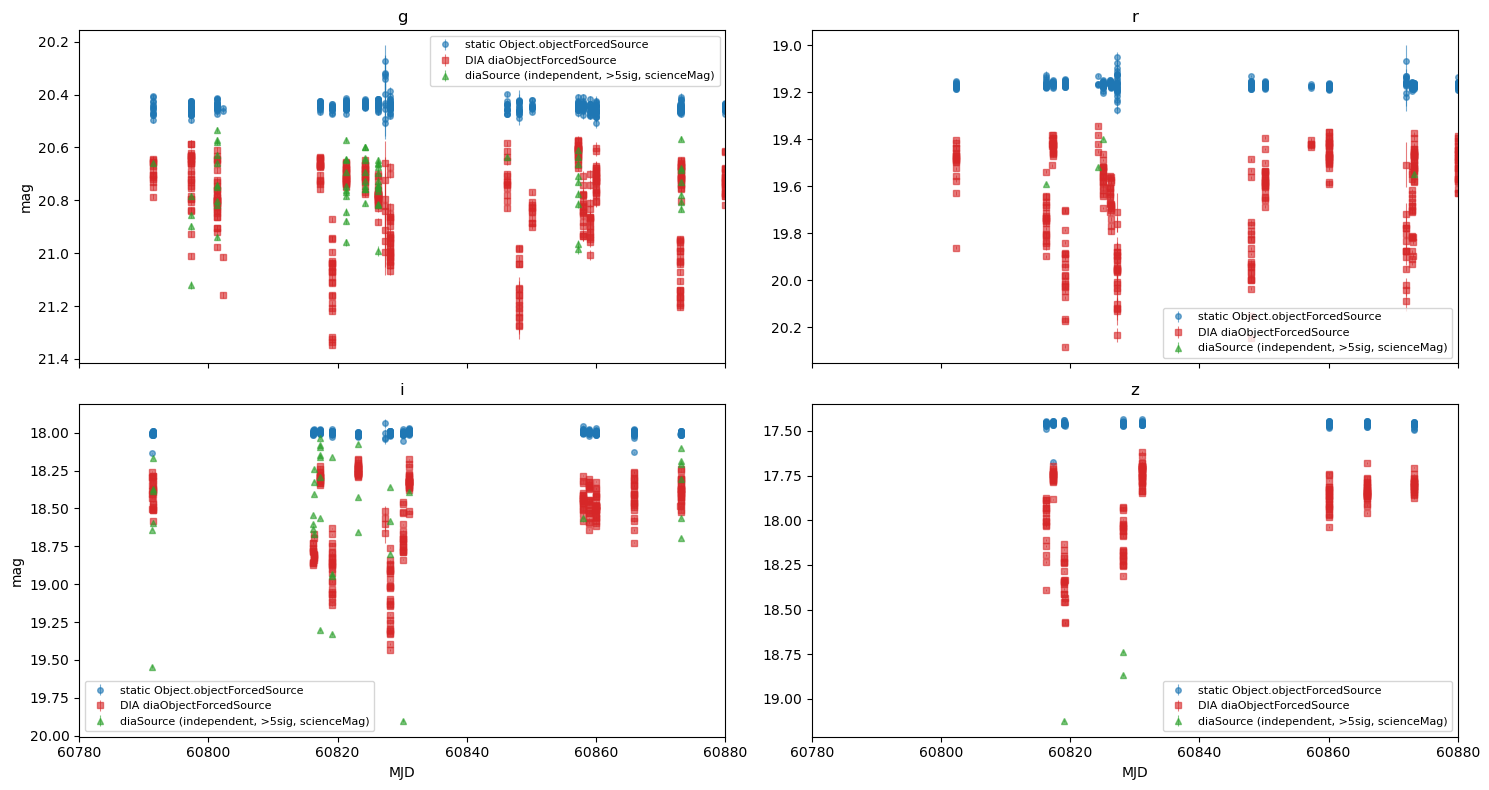

In [125]:
BANDS = "griz"
STREAMS = [(static_stream, 'static Object.objectForcedSource', 'C0', 'o'),
          (dia_forced_stream, 'DIA diaObjectForcedSource', 'C3', 's'),
          (dia_source_stream, 'diaSource (independent, >5sig, scienceMag)', 'C2', '^')]

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
for ax, b in zip(axes.flat, BANDS):
    for stream, label, color, marker in STREAMS:
        m = stream['band'] == b
        if m.sum() == 0:
            continue
        ax.errorbar(stream['t'][m], stream['mag'][m], yerr=stream['err'][m],
                    fmt=marker, ms=4, color=color, alpha=0.6, label=label, elinewidth=0.8)
        ax.legend(fontsize=8, loc='best')
    ax.invert_yaxis()
    ax.set_title(b)
    ax.set_xlim(60780, 60880)
#axes[0, 0].legend(fontsize=8, loc='best')
for ax in axes[1]:
    ax.set_xlabel('MJD')
for ax in axes[:, 0]:
    ax.set_ylabel('mag')

plt.tight_layout()
plt.show()

## 3. Cutout

In [108]:
neighbor_search = lsdb.open_catalog(lsdb_base / "object_collection",
                                    columns=["objectId", "coord_ra", "coord_dec", "r_psfMag", "refExtendedness"])
neighbors = neighbor_search.cone_search(ra=target_ra, dec=target_dec, radius_arcsec=10).compute()
cs2 = SkyCoord(neighbors['coord_ra'].to_numpy() * u.deg, neighbors['coord_dec'].to_numpy() * u.deg)
sep2 = c0.separation(cs2).arcsec
order = np.argsort(sep2)
for i in order:
    print(f"  objectId={neighbors['objectId'].iloc[i]}  sep={sep2[i]:.2f}arcsec  "
          f"r_psfMag={neighbors['r_psfMag'].iloc[i]:.2f}  ext={neighbors['refExtendedness'].iloc[i]}")

# closest = the target's own static counterpart; next closest = the actual neighbor
other = [i for i in order if neighbors['objectId'].iloc[i] != static_id]
neighbor_i = other[0]
neighbor_ra = neighbors['coord_ra'].iloc[neighbor_i]
neighbor_dec = neighbors['coord_dec'].iloc[neighbor_i]
print(f"\nnearest other source: sep={sep2[neighbor_i]:.2f} arcsec, r={neighbors['r_psfMag'].iloc[neighbor_i]:.2f}")

Computing Catalog:   0%|          | 0/2 [00:00<?, ?it/s]

  objectId=744856867972327105  sep=0.66arcsec  r_psfMag=19.17  ext=1.0
  objectId=744856867972326817  sep=6.20arcsec  r_psfMag=21.77  ext=0.0
  objectId=744856867972326821  sep=8.08arcsec  r_psfMag=24.54  ext=<NA>
  objectId=744856867972326824  sep=8.09arcsec  r_psfMag=25.49  ext=<NA>
  objectId=744856867972326818  sep=9.15arcsec  r_psfMag=21.99  ext=1.0
  objectId=744856867972326825  sep=9.35arcsec  r_psfMag=26.80  ext=1.0

nearest other source: sep=6.20 arcsec, r=21.77


In [109]:
def get_cutout_exposure(ra, dec, fov_deg, band='r'):
    res = sia.search(pos=(ra, dec, fov_deg), calib_level=3, dpsubtype='lsst.deep_coadd')
    tx = np.where(np.array(res['lsst_band']) == band)[0]
    rec = res.getrecord(int(tx[0]))
    dl = discovery.get_datalink_results(rec)
    sq = SodaQuery.from_resource(dl, dl.get_adhocservice_by_id("cutout-sync-exposure"),
                                 session=get_pyvo_auth())
    sq.circle = (ra, dec, fov_deg)
    cutout_bytes = sq.execute_stream().read()
    sq.raise_if_error()
    import io
    return read_archive(io.BytesIO(cutout_bytes))

cutout_fov = 0.003  # deg, ~10.8 arcsec radius -- comfortably covers a few-arcsec-separation pair
cut = get_cutout_exposure(target_ra, target_dec, cutout_fov)

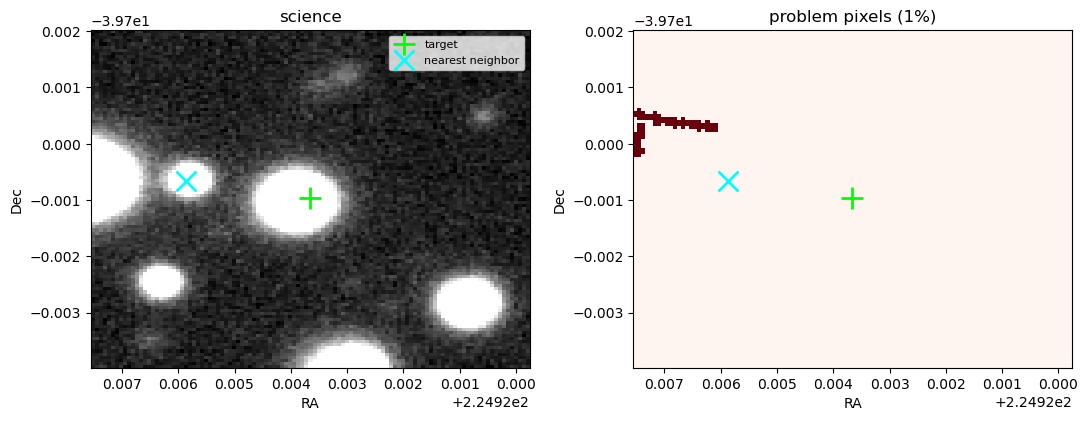

In [128]:
from astropy.visualization import ZScaleInterval, LinearStretch, ImageNormalize

bbox, sky = cut.bbox, cut.sky_projection
c00 = sky.pixel_to_sky(x=bbox.x.min, y=bbox.y.min)
c10 = sky.pixel_to_sky(x=bbox.x.max, y=bbox.y.min)
c01 = sky.pixel_to_sky(x=bbox.x.min, y=bbox.y.max)
ext = (c00.ra.degree, c10.ra.degree, c00.dec.degree, c01.dec.degree)

PROBLEM_BITS_PLANES = ["SATURATED", "COSMIC_RAY", "INTERPOLATED", "DETECTION_EDGE"]
cmask = cut.mask
flagged = np.zeros(cmask.bbox.shape, dtype=bool)
for plane in PROBLEM_BITS_PLANES:
    flagged |= cmask.get(plane)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
norm = ImageNormalize(cut.image.array, interval=ZScaleInterval(), stretch=LinearStretch())
axes[0].imshow(cut.image.array, origin='lower', cmap='gray', extent=ext, norm=norm)
axes[0].set_title("science")
axes[1].imshow(flagged, origin='lower', cmap='Reds', extent=ext, vmin=0, vmax=1)
axes[1].set_title(f"problem pixels ({flagged.mean():.0%})")

for ax in axes:
    ax.plot(target_ra, target_dec, '+', ms=16, mew=2, color='lime', label='target')
    ax.plot(neighbor_ra, neighbor_dec, 'x', ms=14, mew=2, color='cyan', label='nearest neighbor')
    ax.set_xlim(ext[0], ext[1]); ax.set_ylim(ext[2], ext[3])
    ax.set_xlabel("RA"); ax.set_ylabel("Dec")
axes[0].legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()